In [18]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

In [19]:
# fetch data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]
print(y)
print(X[1])

['5' '0' '4' ... '4' '5' '6']
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  51 159 253 159  50   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252
 253 122   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 163 252 252 252 

In [20]:
#X is uint8 ==> turn to float to divide and store back
#y turns fro char to float ==>turn it to int
X=X.astype(float)
X/=255.0
y=(y=='8').astype(int)

print(y)
print(X[1])

[0 0 0 ... 0 0 0]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.  

In [21]:
from sklearn.decomposition import PCA
X_pca=PCA(n_components=60).fit_transform(X)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [23]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [24]:
def calculate_gradient(theta, X, y):
    m=y.size
    return X.T @ (sigmoid(X@theta)-y)/m


In [25]:
def predict_prob(X, theta):
        X_b=np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
        return sigmoid(X_b @ theta)


In [26]:
def gradient_descent(X, y, alpha=0.1, num_iter=100, tolerance=1e-7):
    X_b=np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
    theta=np.zeros(X_b.shape[1])
    for i in range(num_iter):
        grad=calculate_gradient(theta,X_b,y)
        theta-=alpha*grad
        if np.linalg.norm(grad)<tolerance:
            break
    return theta

In [27]:

def predict(X, theta, threshold=0.5):
    return (predict_prob(X, theta)>=threshold).astype(int)

In [28]:
theta_hat=gradient_descent(X_train,y_train,alpha=0.1,num_iter=15000)
print(theta_hat)

[-4.78050947 -0.30408041  0.28828816  0.19233962  0.57169688  0.90966963
  0.24574312 -0.3702626  -1.15482836 -0.09416195  0.07113442 -0.3706353
 -0.20220059 -1.20966889  0.68470316  0.56992707 -0.27293807 -0.03819086
 -0.10512556  0.70642725  0.3578168   0.23386734  0.12958594  0.79078116
  0.21364598 -0.04995046 -0.17261195 -0.5882796  -0.44424449 -0.51388786
  0.43475172  0.20171751  0.63356874 -0.43341758  0.19427043 -0.28459177
  0.39274426 -0.31482134 -0.20458665  0.13221041 -0.26477407  0.17768401
 -0.39193372 -0.35534807 -0.0881125  -0.57743974 -0.21724496  0.27302878
  0.10146921 -0.48624283  0.52329105 -0.58659575  0.33445451  0.21582713
  0.08624411  0.57735917  0.10779514 -0.54713087 -0.05037571 -0.09959553
  0.44402759]


In [29]:
y_pred_train=predict(X_train,theta_hat)
y_pred_test=predict(X_test,theta_hat)


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay
train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)
print("train_acc: ",train_acc)
print("test_acc: ",test_acc)

train_acc:  0.9570714285714286
test_acc:  0.9571428571428572


In [31]:
train_per=precision_score(y_train,y_pred_train)
test_per=precision_score(y_test,y_pred_test)
print("train_per: ",train_per)
print("test_per: ",test_per)

train_per:  0.845356176735798
test_per:  0.8494921514312096


In [32]:
train_recall=recall_score(y_train,y_pred_train)
test_recall=recall_score(y_test,y_pred_test)
print("train_recall: ",train_recall)
print("test_recall: ",test_recall)


train_recall:  0.6858083394294074
test_recall:  0.6779661016949152


In [33]:
train_f1=f1_score(y_train,y_pred_train)
test_f1=f1_score(y_test,y_pred_test)
print("train_f1: ",train_f1)
print("test_f1: ",test_f1)


train_f1:  0.7572697899838449
test_f1:  0.7540983606557377


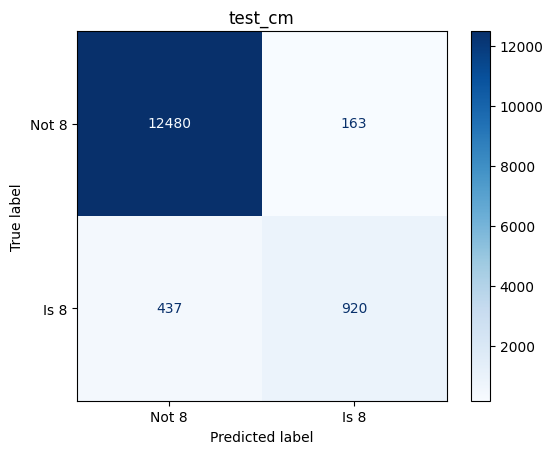

In [34]:
import matplotlib.pyplot as plt
# train_cm = confusion_matrix(y_train, y_pred_train)
test_cm = confusion_matrix(y_test, y_pred_test)
# disp = ConfusionMatrixDisplay(confusion_matrix=train_cm, display_labels=["Not 8", "Is 8"])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("train_cm")
# plt.show()
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=["Not 8", "Is 8"])
disp.plot(cmap=plt.cm.Blues)
plt.title("test_cm")
plt.show()

train_acc:  0.9531428571428572
test_acc:  0.9537857142857142
train_per:  0.8416626621816434
test_per:  0.8521825396825397
train_recall:  0.6406364301389905
test_recall:  0.6330140014738393
train_f1:  0.7275181723779854
test_f1:  0.7264270613107823


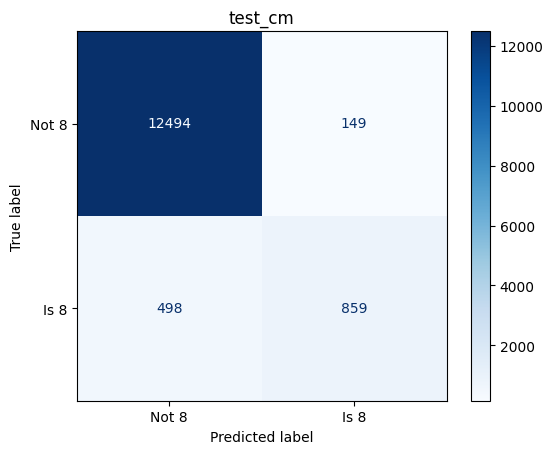

In [35]:
X_pca=PCA(n_components=30).fit_transform(X)
X_train, X_test, y_train, y_test=train_test_split(X_pca, y, test_size=0.2, random_state=42)
theta_hat=gradient_descent(X_train,y_train,alpha=0.1,num_iter=15000)
y_pred_train=predict(X_train,theta_hat)
y_pred_test=predict(X_test,theta_hat)
train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)
print("train_acc: ",train_acc)
print("test_acc: ",test_acc)
train_per=precision_score(y_train,y_pred_train)
test_per=precision_score(y_test,y_pred_test)
print("train_per: ",train_per)
print("test_per: ",test_per)
train_recall=recall_score(y_train,y_pred_train)
test_recall=recall_score(y_test,y_pred_test)
print("train_recall: ",train_recall)
print("test_recall: ",test_recall)
train_f1=f1_score(y_train,y_pred_train)
test_f1=f1_score(y_test,y_pred_test)
print("train_f1: ",train_f1)
print("test_f1: ",test_f1)
test_cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=["Not 8", "Is 8"])
disp.plot(cmap=plt.cm.Blues)
plt.title("test_cm")
plt.show()

train_acc:  0.959375
test_acc:  0.9593571428571429
train_per:  0.85391265794724
test_per:  0.8568840579710145
train_recall:  0.7044623262618873
test_recall:  0.6971260132645541
train_f1:  0.7720212446136887
test_f1:  0.7687931735067046


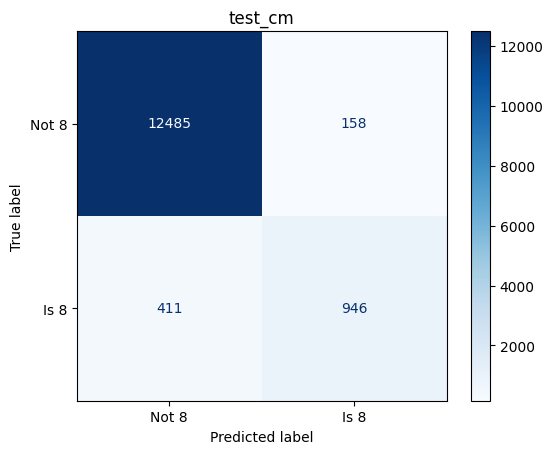

In [36]:
X_pca=PCA(n_components=0.95).fit_transform(X)
X_train, X_test, y_train, y_test=train_test_split(X_pca, y, test_size=0.2, random_state=42)
theta_hat=gradient_descent(X_train,y_train,alpha=0.1,num_iter=15000)
y_pred_train=predict(X_train,theta_hat)
y_pred_test=predict(X_test,theta_hat)
train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)
print("train_acc: ",train_acc)
print("test_acc: ",test_acc)
train_per=precision_score(y_train,y_pred_train)
test_per=precision_score(y_test,y_pred_test)
print("train_per: ",train_per)
print("test_per: ",test_per)
train_recall=recall_score(y_train,y_pred_train)
test_recall=recall_score(y_test,y_pred_test)
print("train_recall: ",train_recall)
print("test_recall: ",test_recall)
train_f1=f1_score(y_train,y_pred_train)
test_f1=f1_score(y_test,y_pred_test)
print("train_f1: ",train_f1)
print("test_f1: ",test_f1)
test_cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=["Not 8", "Is 8"])
disp.plot(cmap=plt.cm.Blues)
plt.title("test_cm")
plt.show()